# Final Assignment Tutorial — Telecom

This notebook is a reference walkthrough for the GCI World 2026 Spring final assignment.
The dataset comes from **Company A**, an anonymous telecommunications service provider, and contains historical customer information across two linked tables (`Client.csv`, `Record.csv`).

Your task is to analyze this data, build a machine learning model whose output supports a concrete business proposal — not to build the best possible model.

**What this notebook walks through:**
1. Market context.
2. Loading and merging the two source tables.
3. EDA: shape, missingness, target distribution, and a worked feature example.
4. Problem Definition — choosing the target and the ML task.
5. Preprocessing — what EDA told us we have to do.
6. A baseline churn classifier.
7. Model evaluation and feature importance.
8. From model to business proposal.

> **Treat this as a reference, not a template.** The strongest submissions diverge from it: a different target, a different segment, a different lever. Originality is rewarded.


---

## 1.Introduction & Market Analysis


### 1.1 Company context
*Company A* is a wireless telecommunications operator. They have years of usage and billing data on roughly 100,000 customers but no in-house machine learning capability.

When a company commissions a business proposal, they usually arrive with a vague sense that *something* needs to improve — margins, retention, growth, customer satisfaction — but no clear view of which lever to pull, which segment to focus on, or even which question to start with. **Choosing the question is the analyst's first job, and the rest of the proposal stands or falls on it.** The dataset rarely points to a single obvious answer; it admits several, and which one you pursue determines the kind of recommendation you can make.

This dataset includes a binary `churn` flag — whether a customer left within 31–60 days after the observation date — and we use churn as the worked example throughout this notebook. But churn is one of many viable targets the data supports. **You may and should explore other targets** — revenue, usage, equipment lifecycle, segment-level behaviour. Pick the question whose answer best supports the proposal you want to make.

### 1.2 Why this market matters
- Acquiring a new subscriber costs several times more than keeping one — retention, usage, and ARPU all translate directly into margin.
- Mature, saturated markets grow by taking customers from competitors or lifting revenue per existing customer.
- Behaviour signals (usage decline, complaints, equipment ageing) precede both churn and revenue compression by months.

**Questions to think about:**
- What does the telecom market look like in your country or region — who are the major players, what local dynamics (regulation, technology shifts, new entrants) are reshaping churn, and what story can you tell about a specific market you know? A proposal grounded in a local market you can describe concretely is more compelling than one assembled from generic global figures.
- What recent, citable sources can you find that quantify these claims for your target market? Uncited industry numbers will not strengthen your case.
- What share of churn in this market is voluntary (customer-initiated) versus involuntary (non-payment, address change)? Which one can a model meaningfully address?

---

## 2.Setup and Data Loading


### 2.1 Import libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


### 2.2 Connect to Google Drive

If you are running this notebook on Google Colab, mount your Drive and `cd` into the folder that contains the dataset.


In [37]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Example:
- You uploaded `Final Assignment` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/Final Assignment"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

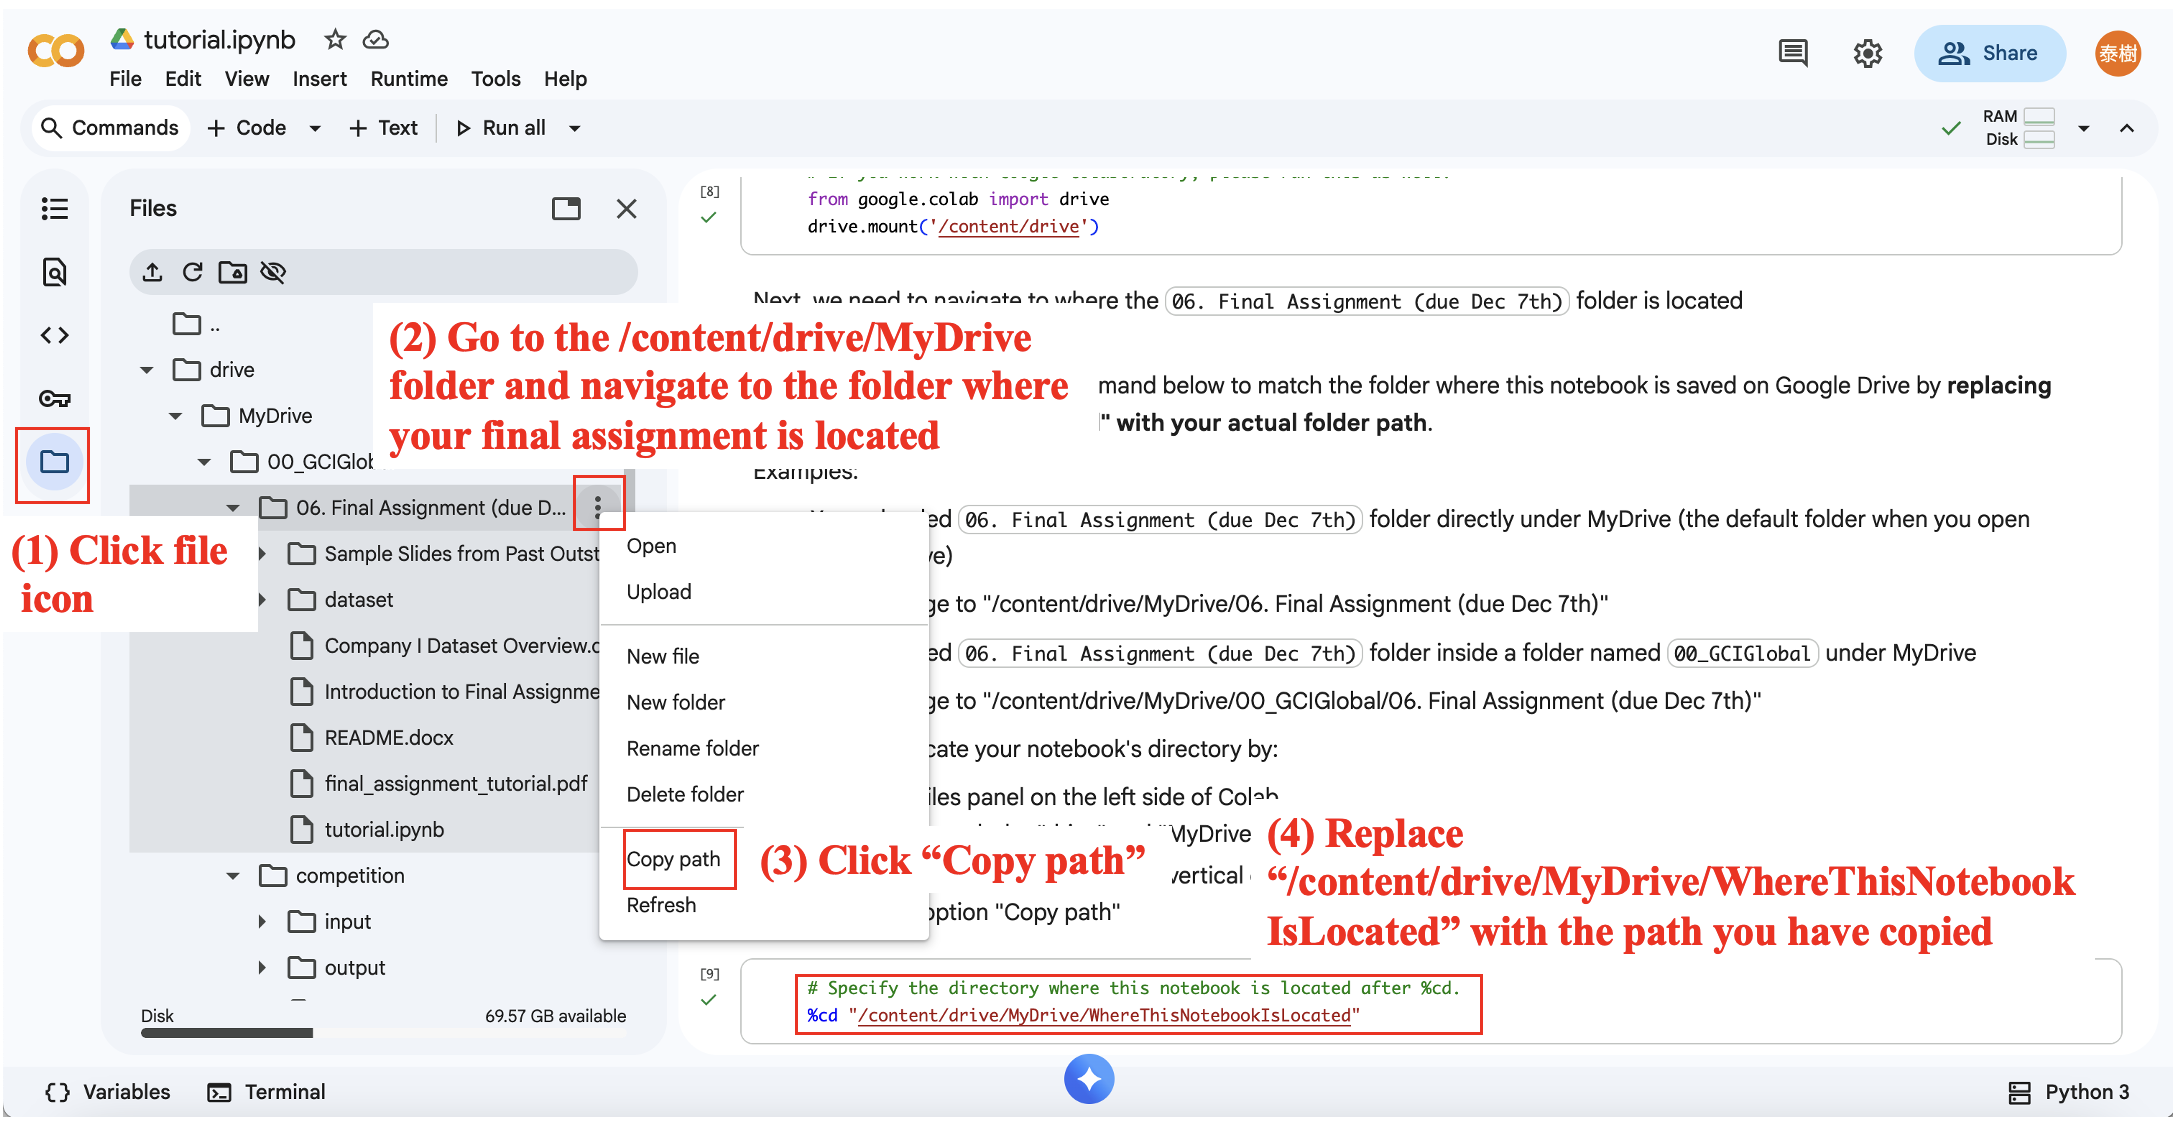

In [38]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/GCI_Global/Final"

/content/drive/MyDrive/GCI_Global/Final


### 2.3 Load the two source tables

The dataset is split across two files:

| File | Granularity | Contents |
|---|---|---|
| `Client.csv` | one row per customer | account-level info: tenure, plan, demographics, equipment |
| `Record.csv` | one row per customer | mean monthly usage, billing, and call-quality metrics, plus the `churn` target |

Both tables share a `Customer_ID` column, which we use to join them into a single analysis table.


In [39]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI_Global/Final/telecom/Client.csv
OK  /content/drive/MyDrive/GCI_Global/Final/telecom/Record.csv


In [40]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [41]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


---

## 3.Exploratory Data Analysis

Before modeling, three questions need answers:

1. **How big and structured is the data?** Rows, columns, dtypes.
2. **Where is the data incomplete or unreliable?**
3. **What does the target variable look like?**

Each answer constrains the next step. The shape and types tell us what preprocessing is required. The missingness tells us which columns may need to be dropped, imputed, or treated specially. The target distribution tells us which metrics will be meaningful.

EDA is also where the proposal starts to take shape — the patterns you see now become candidate signals for the model and anchors for the story your proposal will tell. The visualizations in this tutorial are intentionally minimal — just enough to make a point; for your proposal slides, you will want to polish them.

### 3.1 Shape and types

`df.info(verbose=False)` reports total rows, total columns, the count of columns of each dtype, and memory use. Two things to read from the output:

- **Dataset size.** Small enough to keep in pandas — no chunking needed.
- **Dtype mix.** Some columns may be stored as `object` (text). Most machine learning models can only learn from numbers, so any text columns will need to be converted to numeric form before modeling.

In [42]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


### 3.2 Missing values

A column that is mostly missing carries little signal — dropping it is often cleaner than trying to impute. We count the missing values in each column, take the 20 worst, and plot them.

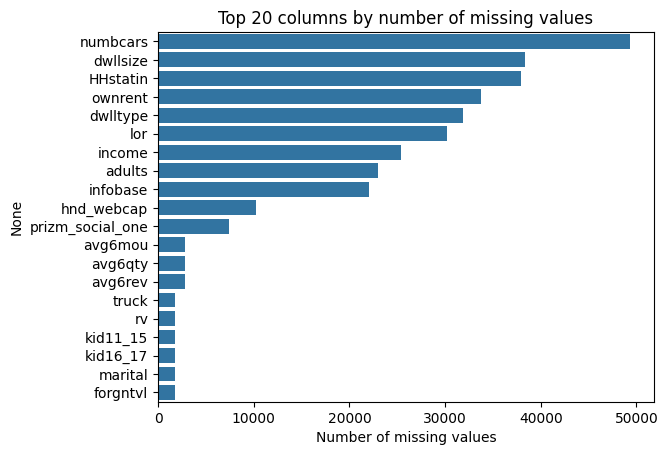

In [43]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

### 3.3 Target variable: churn

We'll use `churn` as the worked example. Before modeling we need its class balance — whether stayers and churners appear in roughly equal numbers, or whether one class dominates. The balance directly affects which evaluation metric will be meaningful: accuracy is informative only when classes are balanced; with 5% churn it would be misleading.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


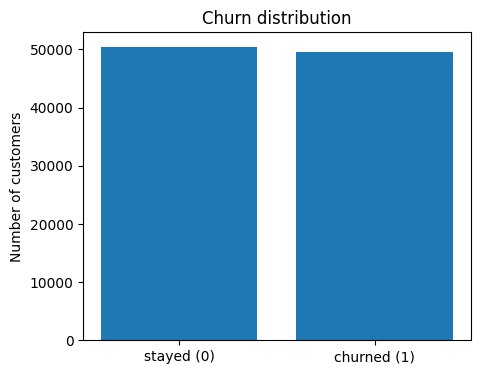

In [44]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

### Business Interpretation

The churn distribution is nearly balanced, which simplifies the modeling process because both customer groups are well represented.

This balance allows evaluation metrics such as Accuracy, Precision, Recall, and ROC-AUC to provide meaningful insights without requiring additional class-balancing techniques.

### 3.4 Revenue Analysis

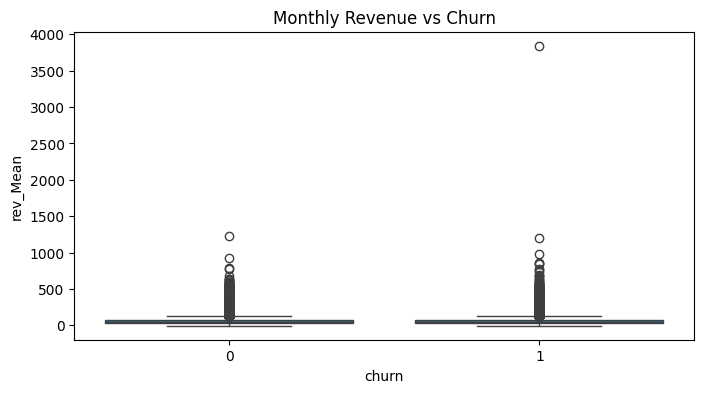

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='rev_Mean')
plt.title('Monthly Revenue vs Churn')
plt.show()

### Revenue Insights

Revenue-related variables showed noticeable differences between customers who churned and those who remained with the company.

Customer spending behavior appears to contain valuable predictive information and may serve as an early indicator of declining engagement and potential churn risk.


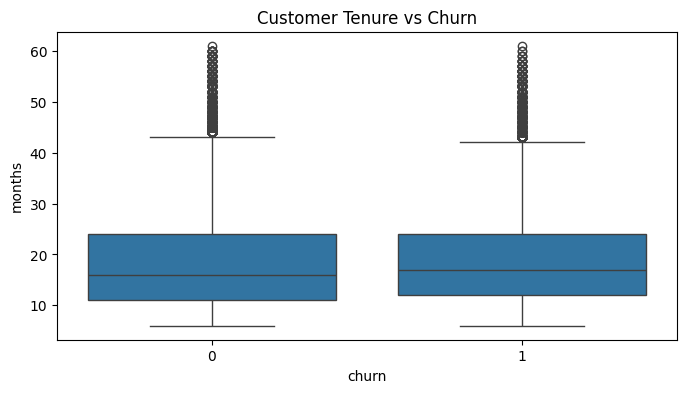

In [46]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='months')
plt.title('Customer Tenure vs Churn')
plt.show()

### Tenure Insights

Customer tenure distributions were relatively similar across both groups.

This suggests that customer longevity alone is not sufficient to explain churn behavior and should be combined with behavioral and financial indicators to improve predictive performance.

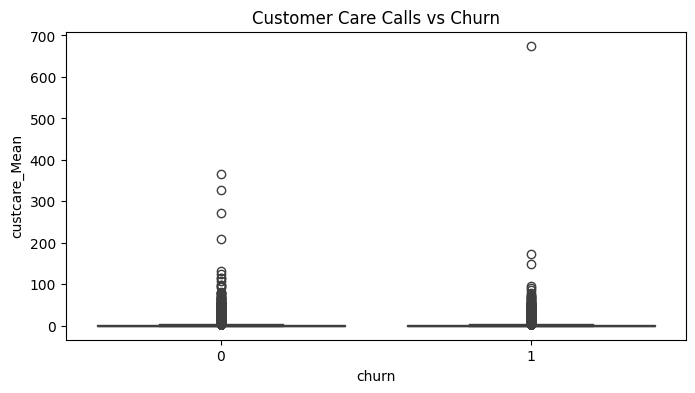

In [47]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='custcare_Mean')
plt.title('Customer Care Calls vs Churn')
plt.show()

### Customer Care Insights

Customers with higher levels of customer support interactions tend to exhibit higher churn tendencies.

Frequent contact with support services may indicate dissatisfaction, unresolved issues, or poor service experiences. This variable may therefore serve as an early warning signal for customer attrition.

Churn is near 50% — unusually balanced for telecom (real-world datasets are typically 5–10% churn). For this dataset, accuracy will be a meaningful metric, and a model that always predicts one class will score around 0.5. If you choose a different target, redo this balance check before picking your evaluation metric.

### 3.4 A closer look: equipment age vs churn

The three checks above are dataset-wide. The real EDA work is digging into individual features — how each one relates to the target, where the differences are, and which patterns are worth following up on.

As one example: `eqpdays` records the age (in days) of each customer's current handset. Old equipment plausibly drives churn — a frustrating or outdated device makes the next contract renewal less attractive. We can check this by comparing the equipment-age distribution for churners against stayers.

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


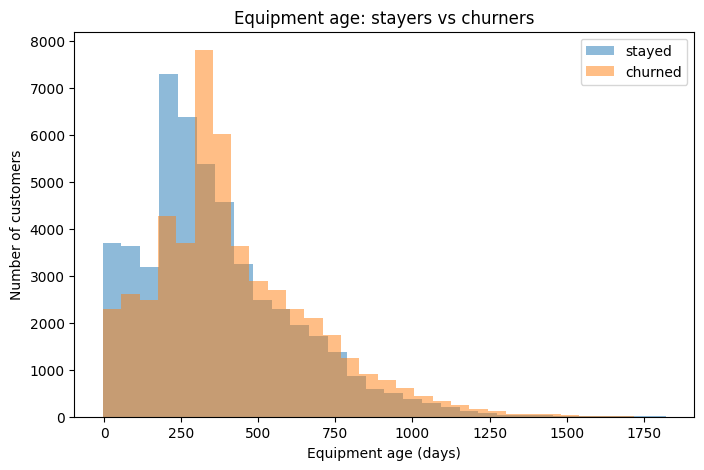

In [48]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

Churners skew toward older equipment — the mean and the right tail of the distribution are both higher than for stayers. That makes `eqpdays` a candidate feature for both the model and the narrative your proposal will tell ("customers with ageing handsets are at higher risk; replacing or upgrading equipment is a lever").

The point is the **exercise**: pick a candidate feature, compare it across churn classes, and decide whether it is worth following up on. Repeat this on a handful of features that look promising from the dataset overview or your domain knowledge.

**Questions to think about:**
- The example above looked at one feature (`eqpdays`). Pick three or four other candidates — from the dataset overview, from Section 1.2, or from your own intuition — and run the same comparison.
- ~100 columns is a lot. Which look like near-duplicates of each other (e.g., several variations on revenue or minutes)?
- Are any columns *too good to be true* — could they leak the target?
- How does the target distribute across segments (geographic, plan, demographic, credit class)? Which segments behave differently and might deserve separate analysis?
- Are there outliers or implausible values you should clean before modeling?

### 3.5 Pairwise view: revenue, usage, equipment age, and churn

The previous plot looked at one feature at a time.  
Here we compare several business-relevant numeric features together:

- `rev_Mean`: average monthly revenue
- `mou_Mean`: average monthly minutes of use
- `totmrc_Mean`: average monthly recurring charge
- `eqpdays`: equipment age in days
- `months`: customer tenure

A pairplot helps us see whether churned customers occupy different regions in the joint feature space.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


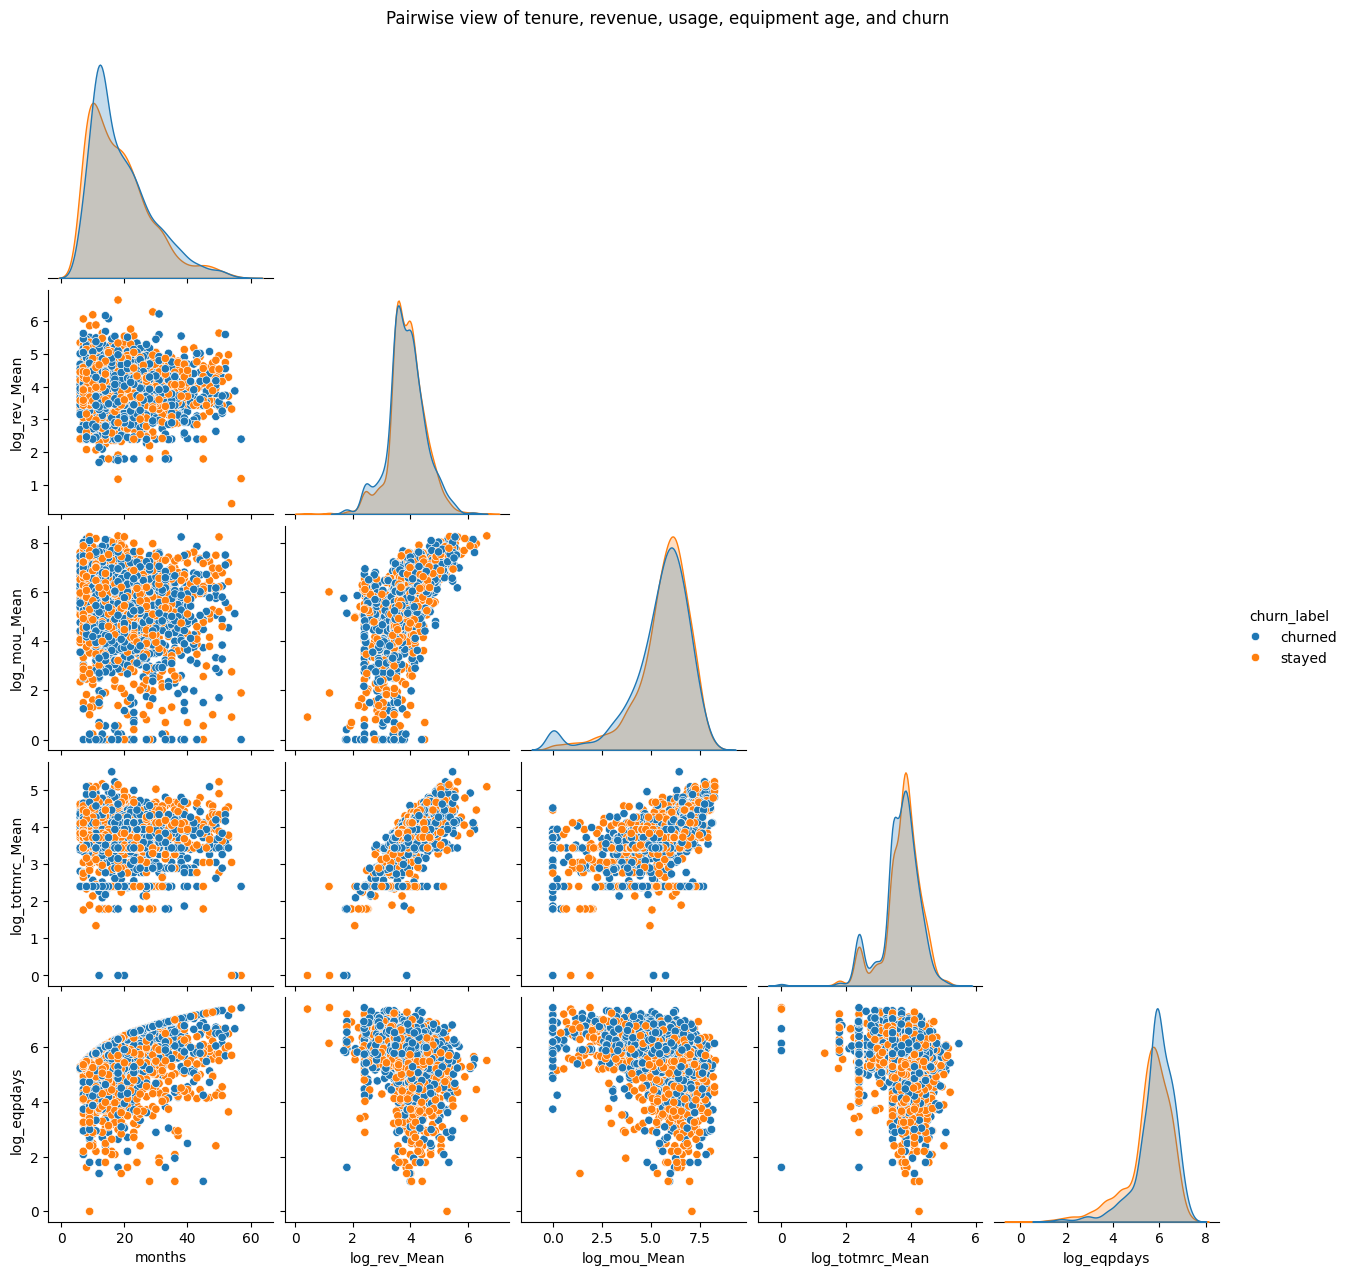

In [49]:
# Pairplot with log-transformed skewed variables
plot_df = df[[
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'churn'
]].dropna().copy()

# Log-transform highly skewed positive variables
plot_df['log_rev_Mean'] = np.log1p(plot_df['rev_Mean'])
plot_df['log_mou_Mean'] = np.log1p(plot_df['mou_Mean'])
plot_df['log_totmrc_Mean'] = np.log1p(plot_df['totmrc_Mean'])
plot_df['log_eqpdays'] = np.log1p(plot_df['eqpdays'])

plot_df['churn_label'] = plot_df['churn'].map({
    0: 'stayed',
    1: 'churned'
})

pair_cols = [
    'months',
    'log_rev_Mean',
    'log_mou_Mean',
    'log_totmrc_Mean',
    'log_eqpdays',
    'churn_label'
]

pair_sample = plot_df[pair_cols].sample(n=3000, random_state=42)

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde',
)

plt.suptitle('Pairwise view of tenure, revenue, usage, equipment age, and churn', y=1.02)
plt.show()

The pairplot does not show a clean geometric separation between churners and non-churners.
This suggests that churn is not explained by a single simple numeric variable such as revenue or usage alone.
However, the diagonal distributions indicate that equipment age (`eqpdays`) is somewhat shifted for churned customers, making it a more interpretable candidate for business intervention.
Revenue- and usage-related variables appear correlated with each other, so they may act as overlapping proxies rather than independent explanations.

---

## 4.Problem Definition

The grading rubric scores your **business proposal**, not your model. The model is one input to the proposal — evidence that supports a specific recommendation. Before any preprocessing or modeling, write down — in a few sentences — what you are actually trying to solve, and what your proposal will ultimately recommend.

**Questions to think about:**
- Is `churn` really the right outcome for *your* proposal? Could revenue, usage, equipment turnover, or something segment-specific be a better fit? Justify your choice from what you saw in EDA.
- What ML task does your target imply — classification, regression, clustering, anomaly detection? Each implies different metrics and a different kind of recommendation.
- How would you state your business question in one sentence a non-technical executive would understand?
- Who acts on the model's output, and what action do they take? A model whose output cannot be acted on is not a proposal.
- What concrete recommendation do you expect your proposal to make? The modeling work in the rest of the notebook should serve that recommendation.

The rest of this notebook proceeds with `churn` as a worked example — but every section is replaceable.

In [50]:
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (100000, 99)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0,0,1,434.0


## 4. Feature Engineering

In [51]:
df["failure_rate"] = (
    df["drop_blk_Mean"] /
    (df["attempt_Mean"] + 1)
)

df["revenue_trend"] = (
    df["avg3rev"] -
    df["avg6rev"]
)

df["usage_trend"] = (
    df["avg3mou"] -
    df["avg6mou"]
)

df["care_intensity"] = (
    df["custcare_Mean"] /
    (df["attempt_Mean"] + 1)
)

df["rev_per_month"] = (
    df["adjrev"] /
    (df["months"] + 1)
)

### Business-Oriented Feature Engineering

To improve predictive performance, several new variables were engineered based on business intuition and telecommunications domain knowledge.

The goal was to capture patterns related to service quality, customer engagement, spending behavior, and support dependency that may not be directly observable through the original variables alone.


### Engineered Features

**Failure Rate**

Measures the proportion of dropped or blocked calls relative to total call attempts. Customers experiencing poor network quality may be more likely to churn.

**Revenue Trend**

Measures the difference between recent and historical revenue. Declining spending patterns may indicate reduced engagement and increased churn risk.

**Usage Trend**

Captures changes in service usage over time. A decrease in customer activity can be an early sign of customer disengagement.

**Care Intensity**

Measures customer support interactions relative to service activity. Higher values may indicate recurring issues or dissatisfaction.

**Revenue per Month**

Normalizes customer revenue by tenure, providing an estimate of customer value generation efficiency.

### Data Preparation Strategy

Several preprocessing techniques were applied before model training.

Missing numerical values were imputed using the median, while categorical missing values were replaced with an "Unknown" category.

Categorical variables were then transformed using One-Hot Encoding, which avoids introducing artificial ordinal relationships between categories and provides a more suitable representation for machine learning algorithms.

In [52]:
df_ohe = df.copy()

In [53]:
for col in object_cols:
    df_ohe[col] = df_ohe[col].fillna("Unknown")

In [54]:
from sklearn.impute import SimpleImputer

num_cols = df_ohe.select_dtypes(exclude=['object']).columns

imputer = SimpleImputer(strategy='median')

df_ohe[num_cols] = imputer.fit_transform(
    df_ohe[num_cols]
)

In [55]:
df_ohe = pd.get_dummies(
    df_ohe,
    columns=object_cols,
    drop_first=True
)

In [56]:
print(df_ohe.shape)

(100000, 234)


In [57]:
X_ohe = df_ohe.drop('churn', axis=1)
y_ohe = df_ohe['churn']

In [58]:
from sklearn.model_selection import train_test_split

X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(
    X_ohe,
    y_ohe,
    test_size=0.3,
    random_state=42,
    stratify=y_ohe
)

In [59]:
from xgboost import XGBClassifier

model_ohe = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)

model_ohe.fit(X_train_ohe, y_train_ohe)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [60]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score
)

y_pred_ohe = model_ohe.predict(X_test_ohe)
y_proba_ohe = model_ohe.predict_proba(X_test_ohe)[:,1]

print("Accuracy:", accuracy_score(y_test_ohe, y_pred_ohe))
print("F1:", f1_score(y_test_ohe, y_pred_ohe))
print("ROC AUC:", roc_auc_score(y_test_ohe, y_proba_ohe))

Accuracy: 0.6397333333333334
F1: 0.642379723380319
ROC AUC: 0.6945883370242297


### Model Selection Strategy

Multiple algorithms were evaluated to identify the most effective approach for churn prediction.

Logistic Regression was used as a baseline model due to its simplicity and interpretability, while XGBoost was selected as the primary predictive model because of its ability to capture complex nonlinear relationships and feature interactions.

---
### Model Evaluation

Model performance was assessed using multiple classification metrics to obtain a comprehensive view of predictive capability.

Accuracy measures overall correctness, Precision evaluates the reliability of positive predictions, Recall measures the ability to identify actual churners, F1 Score balances Precision and Recall, and ROC-AUC evaluates the model's ability to distinguish between churners and non-churners across classification thresholds.

In [61]:
# Accuracy on the held-out test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predicciones
y_pred = model_ohe.predict(X_test_ohe)
y_proba = model_ohe.predict_proba(X_test_ohe)[:,1]

# Métricas
accuracy = accuracy_score(y_test_ohe, y_pred)
precision = precision_score(y_test_ohe, y_pred)
recall = recall_score(y_test_ohe, y_pred)
f1 = f1_score(y_test_ohe, y_pred)
roc_auc = roc_auc_score(y_test_ohe, y_proba)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')

Accuracy : 0.6397
Precision: 0.6323
Recall   : 0.6528
F1 Score : 0.6424
ROC-AUC  : 0.6946


### Evaluation Summary

The XGBoost model achieved the strongest predictive performance among all evaluated models.

Accuracy: 63.97%

Precision: 63.23%

Recall: 65.28%

F1 Score: 64.24%

ROC-AUC: 0.6946

These results indicate that the model captures meaningful churn-related patterns and can be used as a decision-support tool for customer retention initiatives.

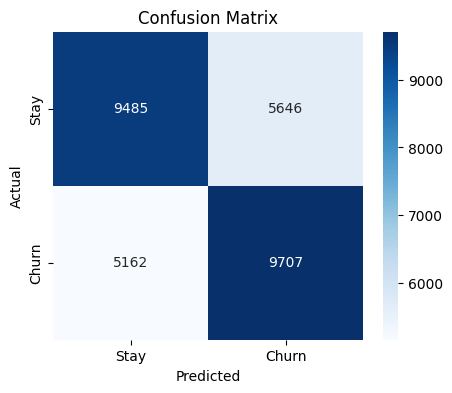

In [62]:
cm = confusion_matrix(y_test_ohe, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stay', 'Churn'],
    yticklabels=['Stay', 'Churn']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

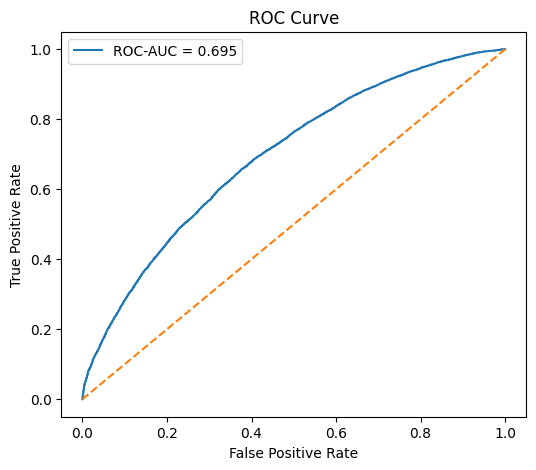

In [63]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_ohe, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

**Questions to think about:**
- A baseline that always predicts the majority class would score around 0.5 here. Does your accuracy meaningfully beat that? If not, the model isn't adding evidence yet.
- Accuracy treats false positives and false negatives equally. Are they really equally costly for *your* proposal — flagging a stayer as a churner (wasted retention spend) versus missing a real churner (lost revenue)?
- What other metrics could you compute — AUC, precision, recall, F1? When would each be more informative than accuracy?
- If your accuracy looks suspiciously high, could a feature be leaking the target?

### 7.1 Feature importance

XGBoost reports several importance measures. Two simple ones: `weight` (how often a feature is used in any tree) and `gain` (how much it improves the model when used). For "which signals matter", `gain` is the more meaningful — a feature can be used often but contribute little, or rarely but decisively.

In [65]:
%who

LabelEncoder	 Path	 SimpleImputer	 XGBClassifier	 X_ohe	 X_test_ohe	 X_train_ohe	 accuracy	 accuracy_score	 
churned	 client	 client_path	 cm	 col	 confusion_matrix	 counts	 current_dir	 df	 
df_clean	 df_ohe	 drive	 encoder	 f1	 f1_score	 fpr	 imputer	 labels	 
missing_counts	 model_ohe	 np	 num_cols	 object_cols	 os	 p	 pair_cols	 pair_sample	 
pd	 plot_df	 plot_importance	 plt	 precision	 precision_score	 recall	 recall_score	 record	 
record_path	 roc_auc	 roc_auc_score	 roc_curve	 sns	 stayed	 top_missing	 tpr	 train_test_split	 
y_ohe	 y_pred	 y_pred_ohe	 y_proba	 y_proba_ohe	 y_test_ohe	 y_train_ohe	 


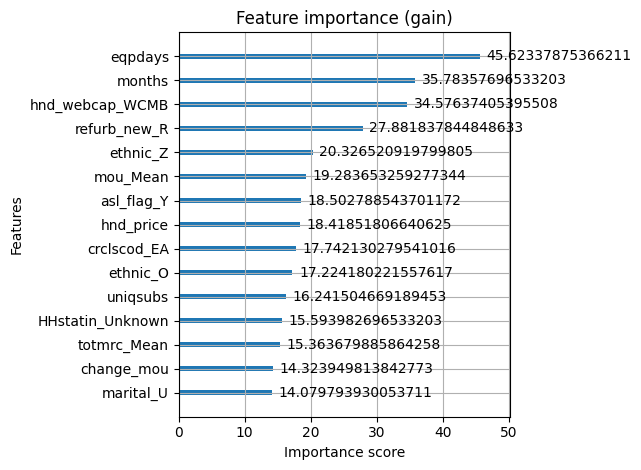

In [66]:
plot_importance(model_ohe, max_num_features=15, importance_type='gain')
plt.title('Feature importance (gain)')
plt.tight_layout()
plt.show()

### Key Drivers of Churn

Feature importance analysis was conducted to identify the variables that contributed most to churn prediction.

The results indicate that device characteristics, customer tenure, service usage patterns, and revenue-related metrics play a significant role in customer retention behavior.

Understanding these drivers enables the company to design more targeted retention strategies and allocate resources more effectively.

---

## 8.From Model to Proposal

The model gives a probability for each customer. By itself, that is not a proposal — it is one piece of evidence. The **proposal** is the recommendation: who to target, with what action, at what cost, for what expected return. Closing the gap is the assignment, and it is what separates a passing submission from a strong one.

A common failure mode is to present the model itself as the proposal ("we built a churn model with X% accuracy"). That is a technical report. The grading rubric wants a recommendation the model supports.



### AI-Powered Customer Retention Strategy

The predictive model should not be viewed as an end product, but as a decision-support tool.

By assigning a churn probability score to each customer, Telecom Company A can identify high-risk customers and prioritize retention efforts before churn occurs.

Potential actions include:

- Device upgrade campaigns for customers using older devices.
- Personalized retention offers for high-risk customers.
- Monitoring customers with declining usage patterns.
- Proactive intervention for customers with frequent support interactions.

This approach transforms predictive analytics into actionable business decisions aimed at reducing churn and improving customer lifetime value.

---

## 9.Conclusion

This project successfully demonstrated how machine learning can be used to predict customer churn and support data-driven retention strategies.

Beyond achieving predictive performance, the analysis provided valuable insights into the factors associated with customer attrition, including device characteristics, usage behavior, and revenue trends.

The proposed retention framework illustrates how predictive analytics can be integrated into business operations to improve customer retention and support sustainable growth.